In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [2]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.models.node_lstm import NodeLSTM

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(<Figure size 2200x600 with 2 Axes>, <Axes: title={'center': 'node: 1'}>)

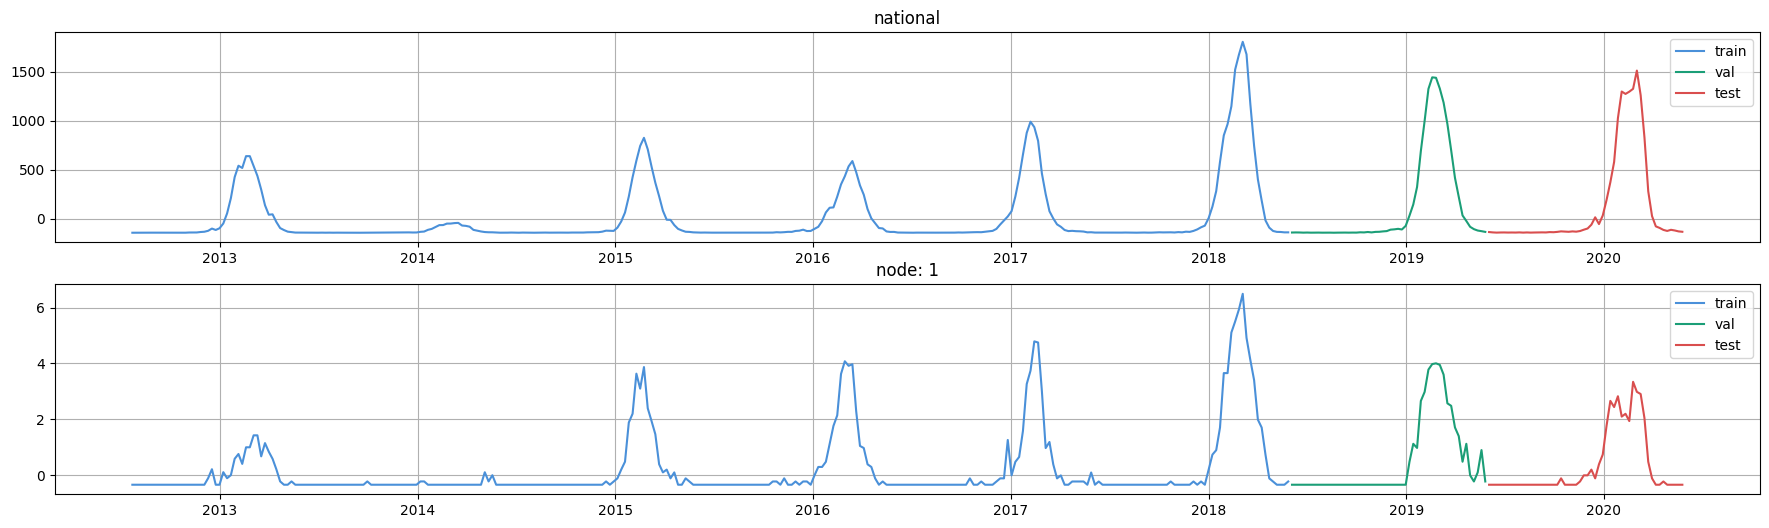

In [3]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(2,8))
epidata.preview()

Dataloader Snapshot: Data(x=[411, 9, 10], y=[411, 1])
Epoch 1 train loss: 1.0422, val loss: 2.2699 ✓ (new best)
Epoch 2 train loss: 0.9539, val loss: 1.8627 ✓ (new best)
Epoch 3 train loss: 0.8380, val loss: 1.3293 ✓ (new best)
Epoch 4 train loss: 0.8220, val loss: 1.2229 ✓ (new best)
Epoch 5 train loss: 0.8097, val loss: 1.1740 ✓ (new best)
Epoch 6 train loss: 0.7992, val loss: 1.1355 ✓ (new best)
Epoch 7 train loss: 0.7905, val loss: 1.1027 ✓ (new best)
Epoch 8 train loss: 0.7830, val loss: 1.0742 ✓ (new best)
Epoch 9 train loss: 0.7764, val loss: 1.0487 ✓ (new best)
Epoch 10 train loss: 0.7703, val loss: 1.0256 ✓ (new best)
Epoch 11 train loss: 0.7646, val loss: 1.0046 ✓ (new best)
Epoch 12 train loss: 0.7594, val loss: 0.9856 ✓ (new best)
Epoch 13 train loss: 0.7546, val loss: 0.9687 ✓ (new best)
Epoch 14 train loss: 0.7502, val loss: 0.9541 ✓ (new best)
Epoch 15 train loss: 0.7467, val loss: 0.9935 (patience: 1/15)
Epoch 16 train loss: 0.7379, val loss: 0.9816 (patience: 2/15)
Epo

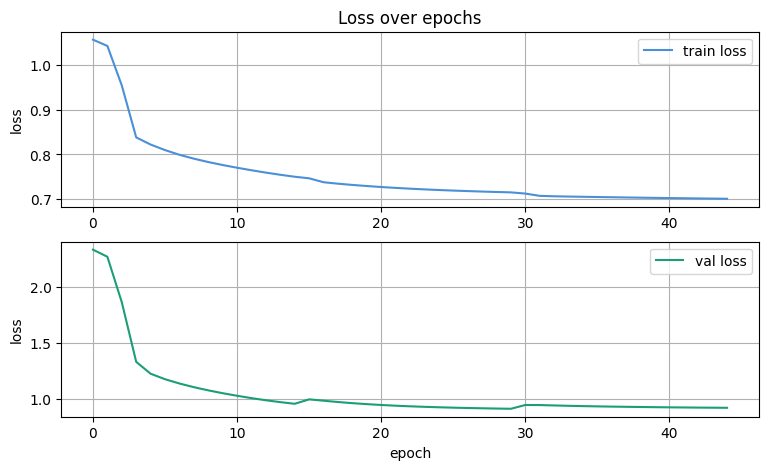

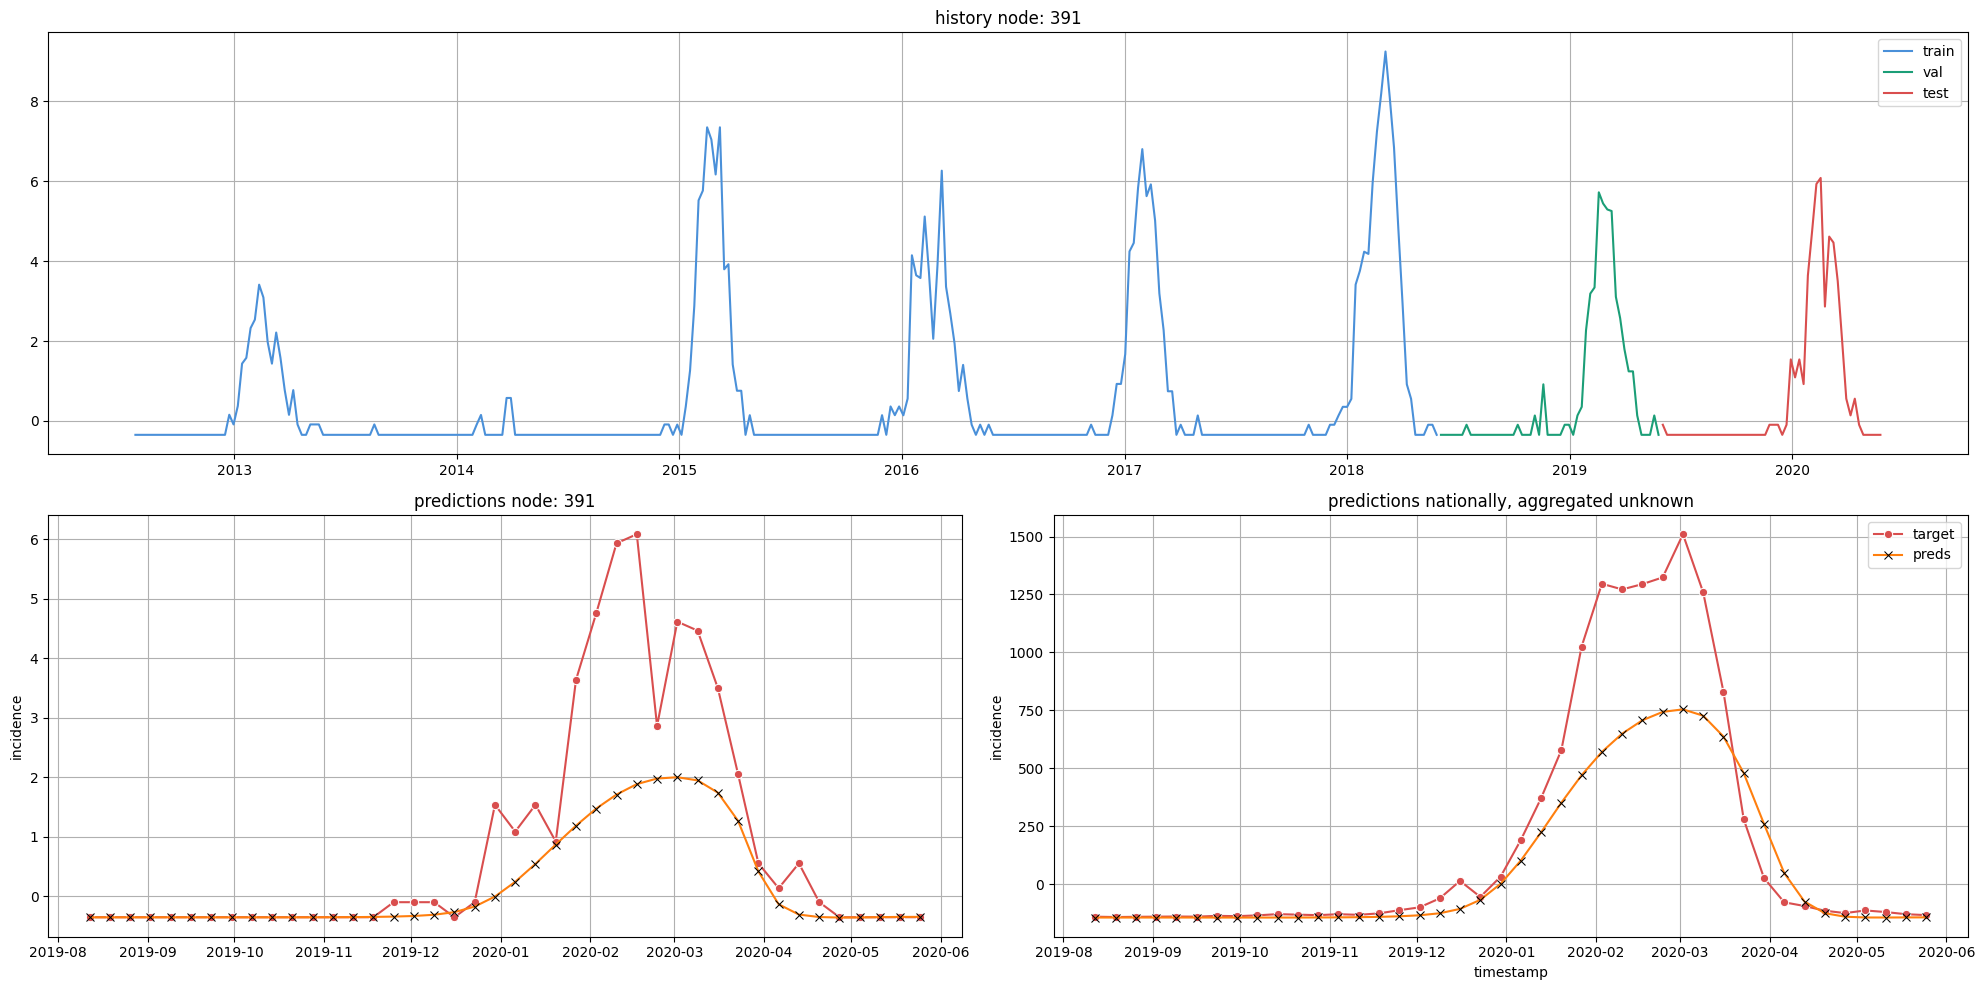

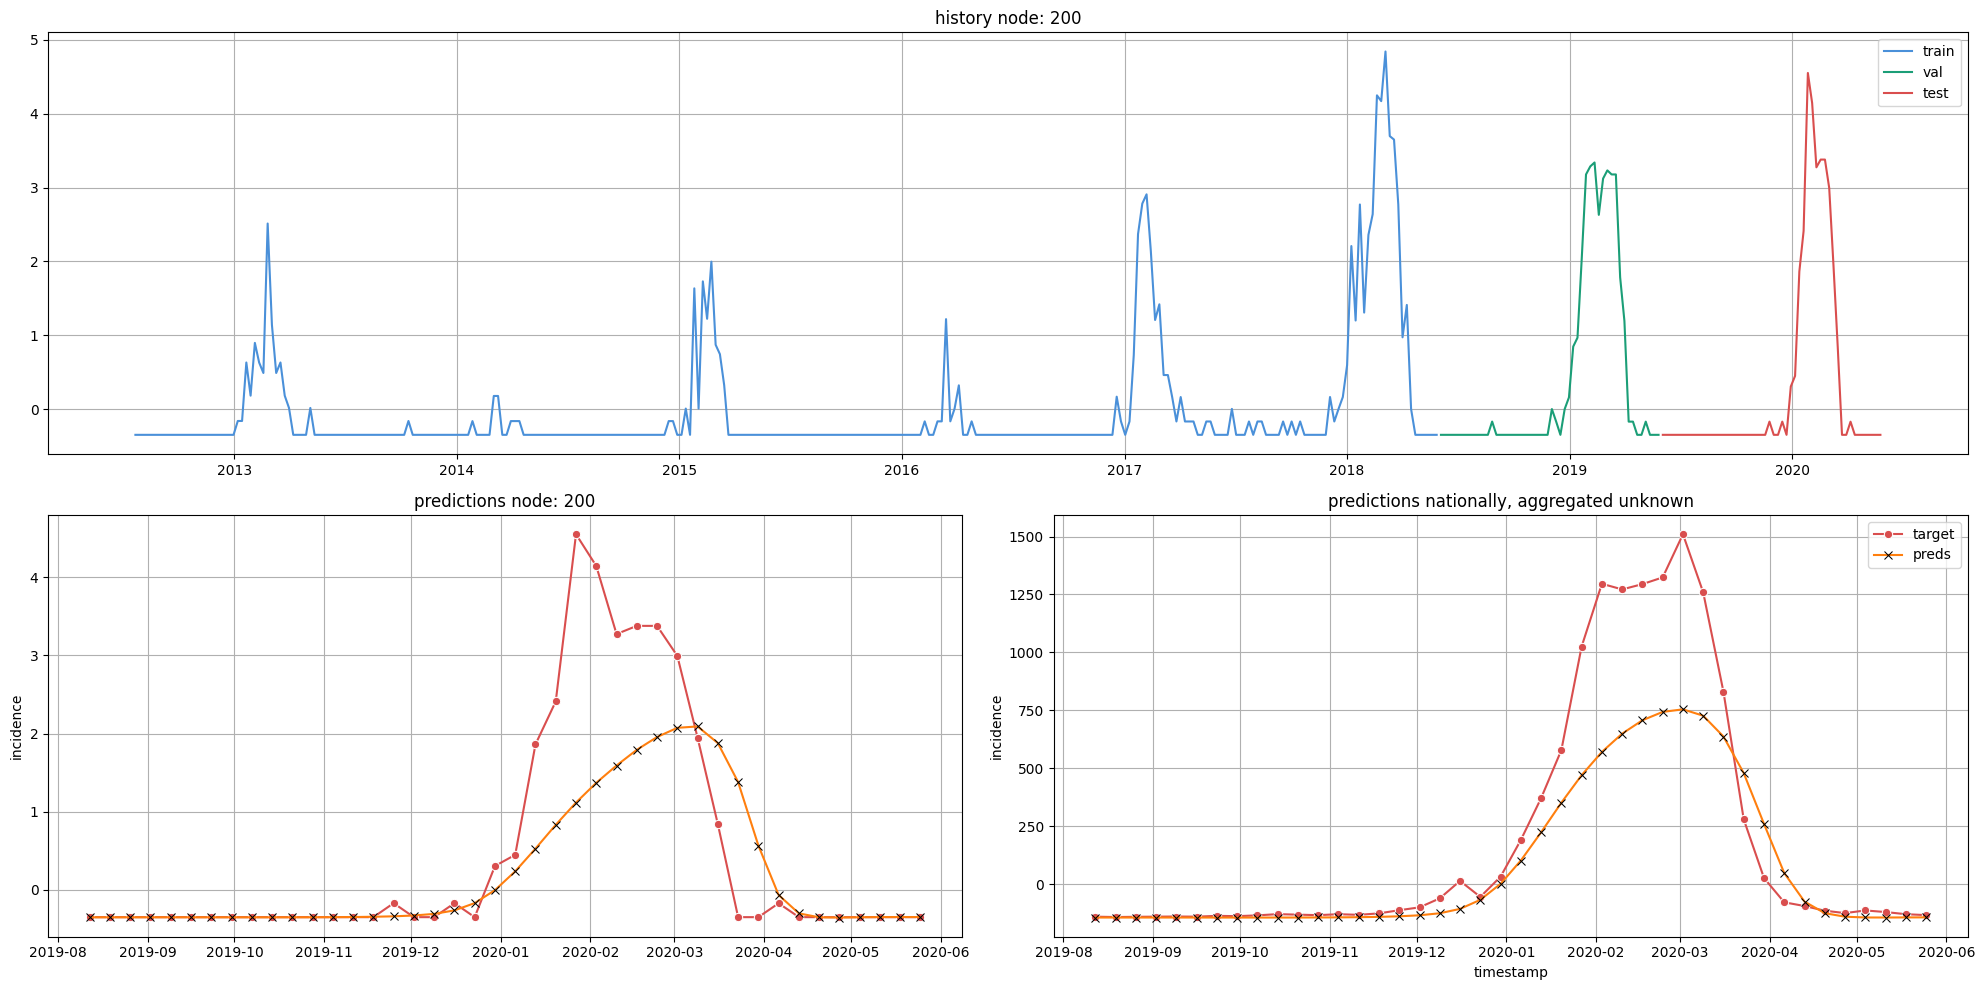

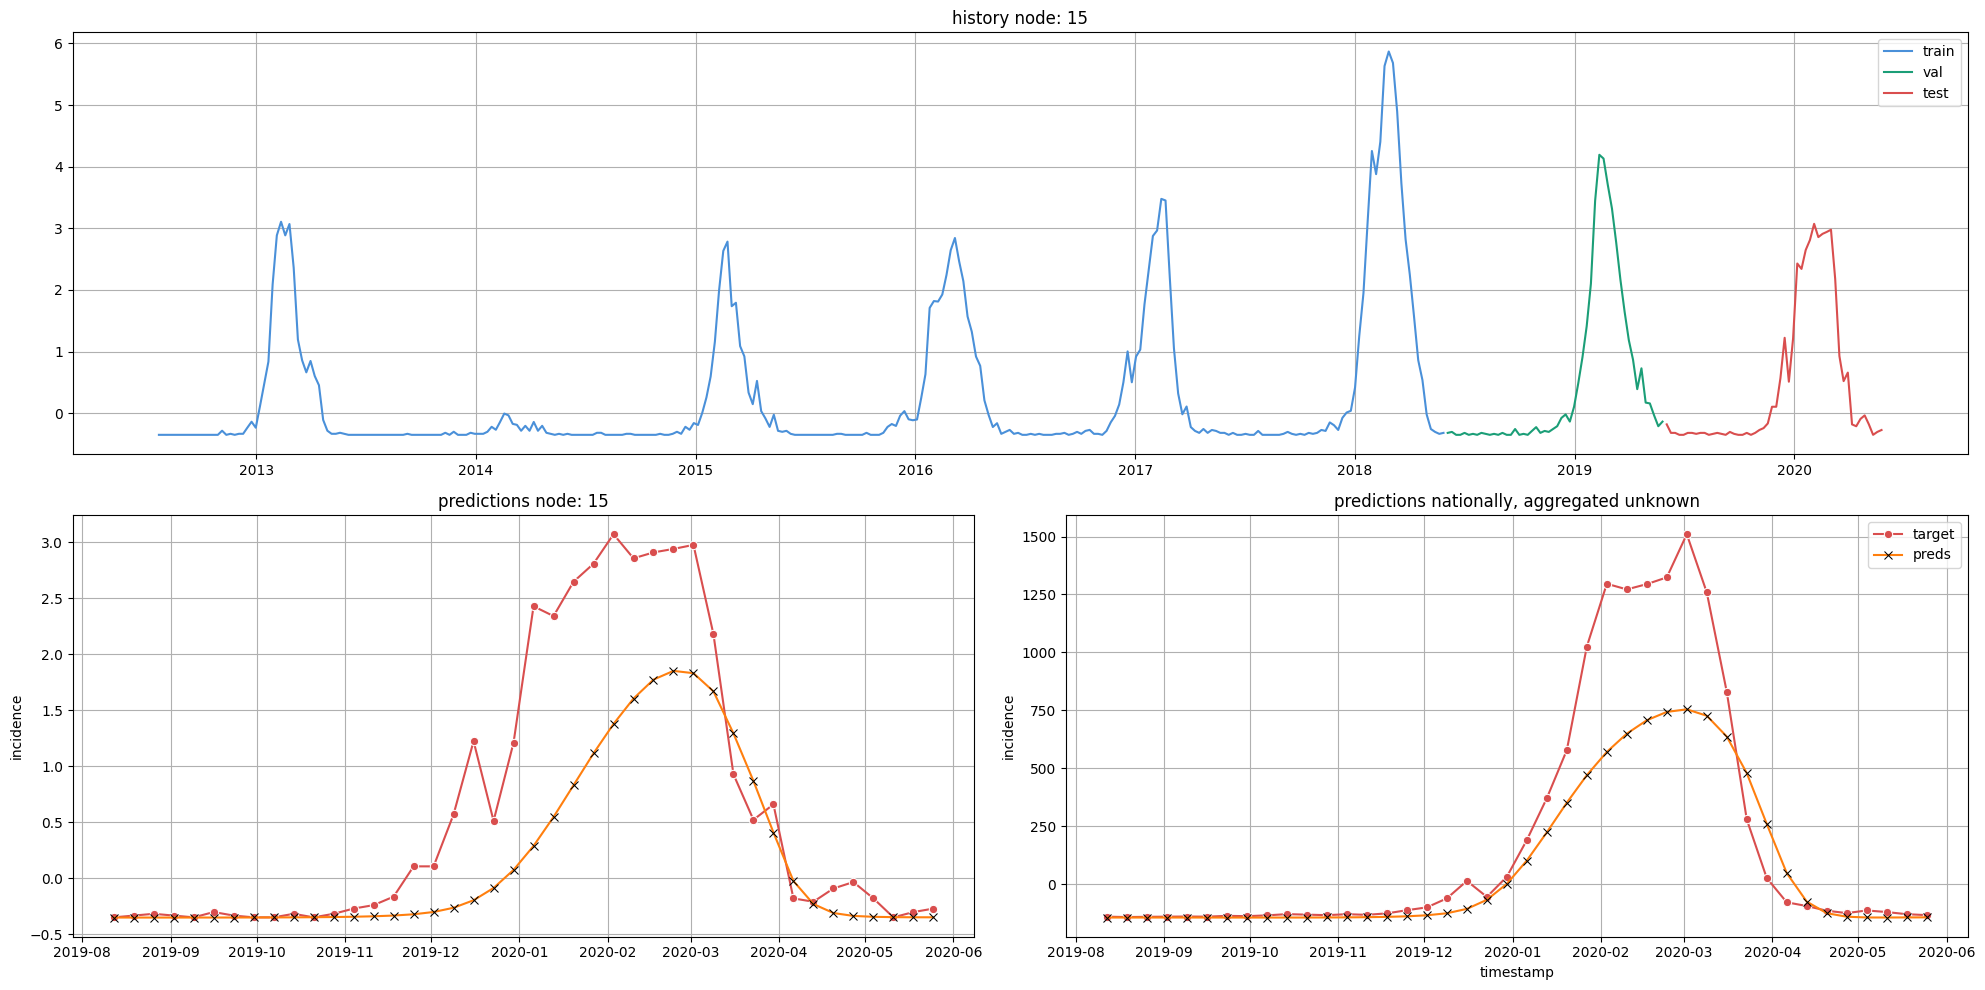

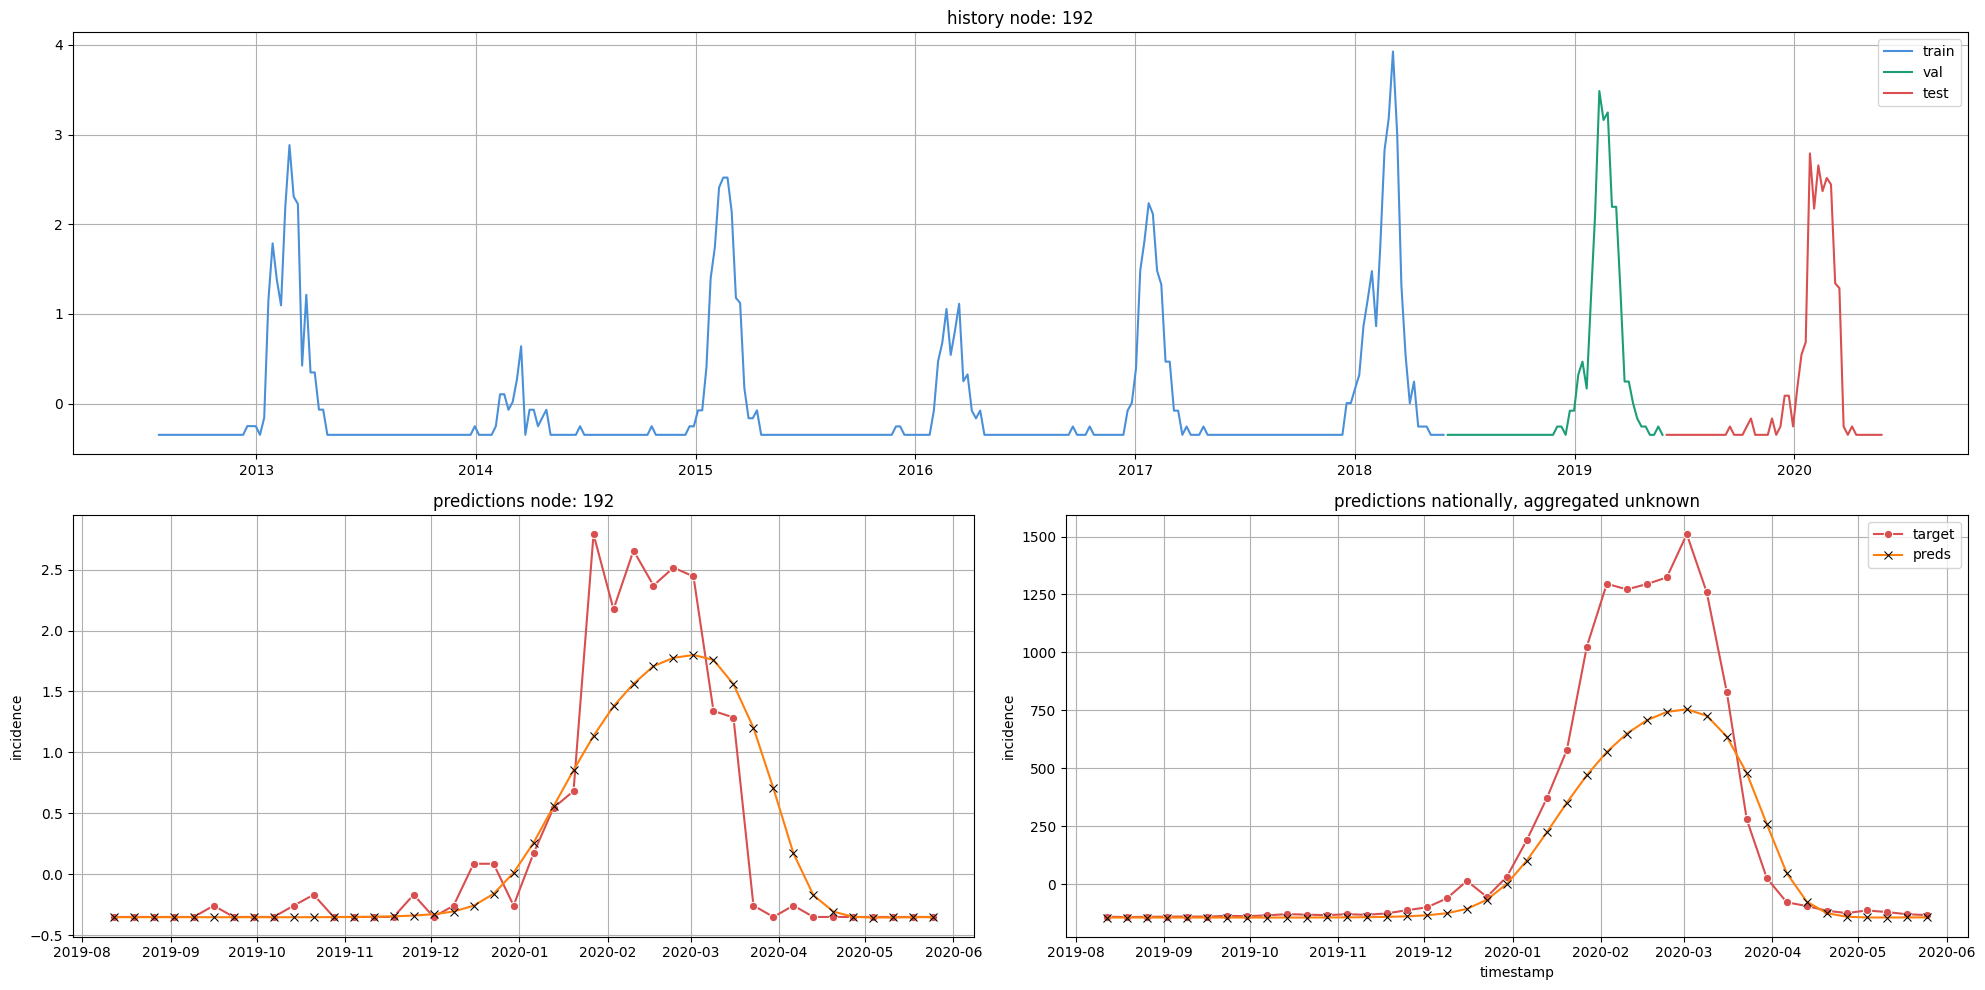

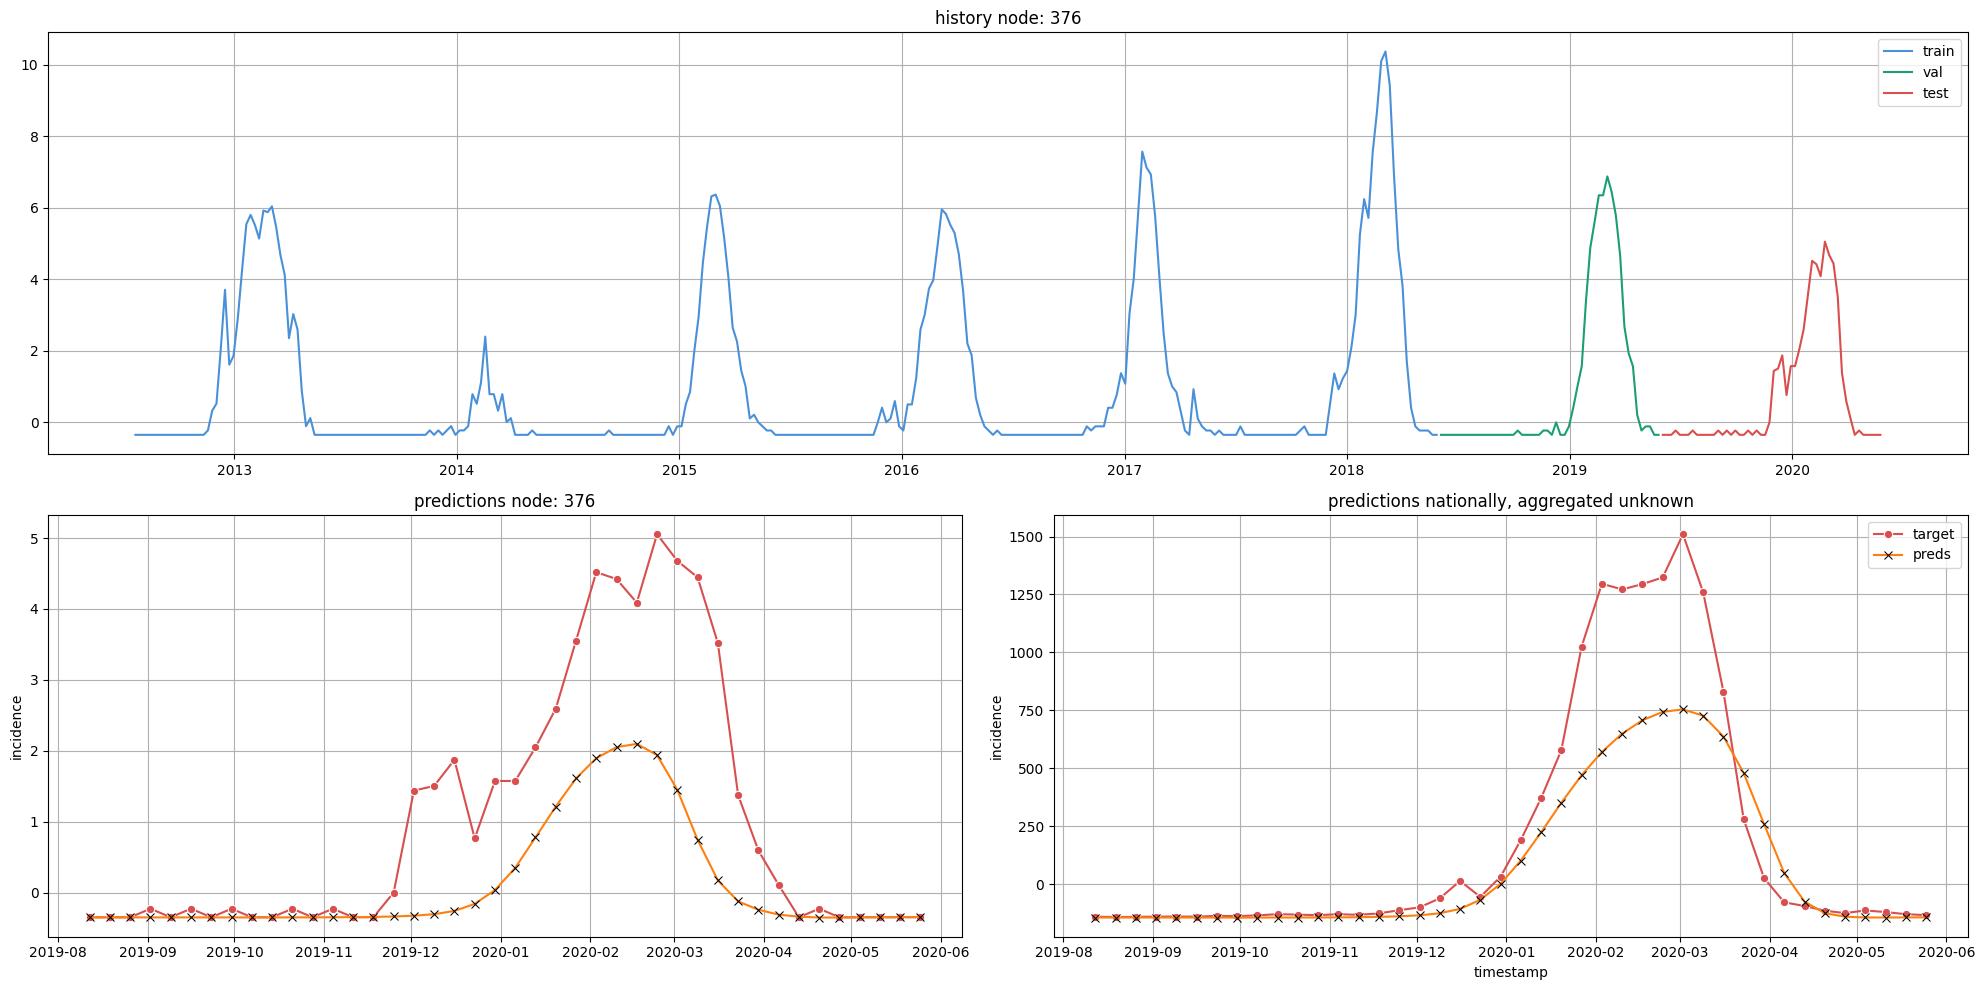

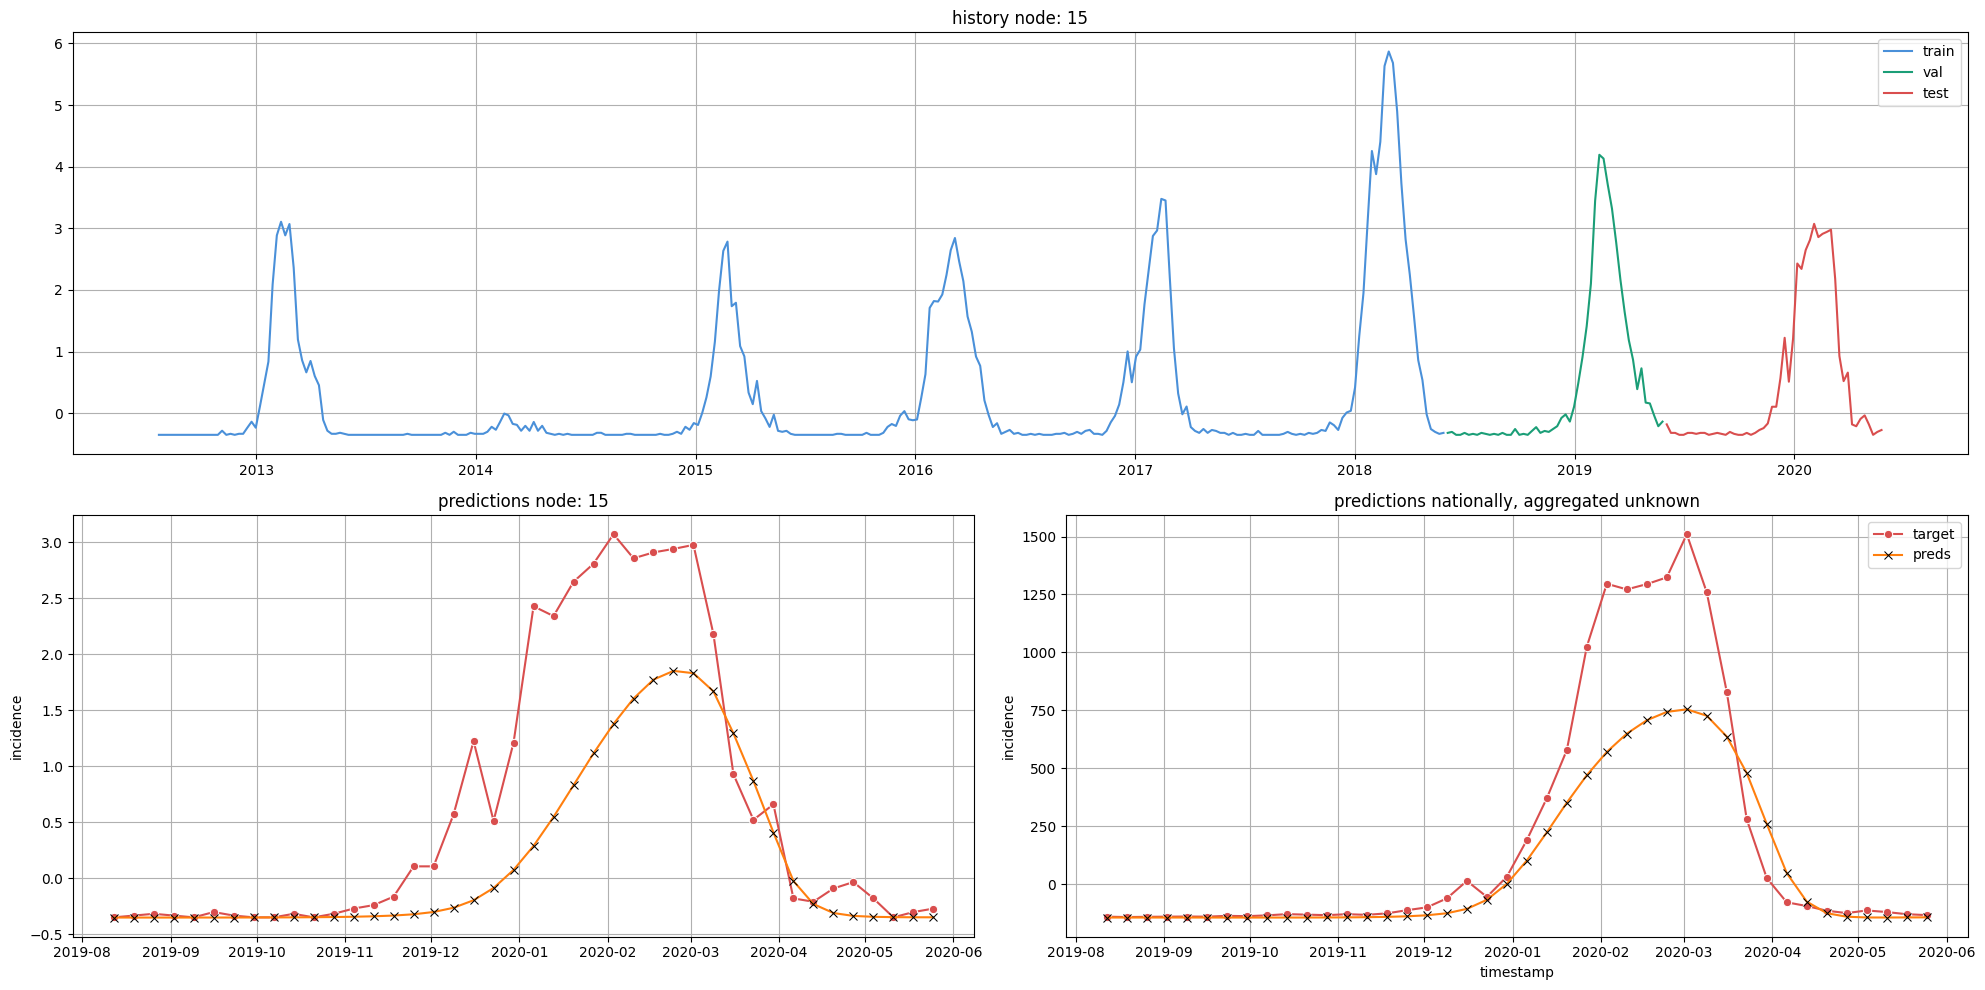

In [6]:
n_epochs = 100


dataloader_NodeLSTM = GNNDataLoader(epidata).construct_dataloaders(periods = 10)
nodelstm_model = NodeLSTM(dataloader_NodeLSTM)

nodelstm_model.set_model_hparams(hidden_size=256, num_layers = 4)

nodelstm_model.set_global_hparams(lr = 0.00001, 
                                  n_epochs = n_epochs,     
                                  optimizer='adam', 
                                  scheduler='step',
                                  scheduler_kwargs={'step_size': 15,
                                                    'gamma' : 0.8},
                                loss = 'mse',
                                min_delta = 1e-4
                                  )

nodelstm_model.train()
nodelstm_model.forecast()
nodelstm_model.show_forecasts(391)
nodelstm_model.show_forecasts(200)
nodelstm_model.show_forecasts(15)

nodelstm_model.show_forecasts(192)
nodelstm_model.show_forecasts(376)
nodelstm_model.show_forecasts(15)